# Deep Neural Networks in TensorFlow to solve MNIST 

#### Load Dependencies

In [1]:
import tensorflow
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from matplotlib import pyplot as plt


In [2]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

In [3]:
(X_train, y_train), (X_valid, y_valid) = mnist.load_data()

In [4]:
X_train.shape

(60000, 28, 28)

In [5]:
type(X_train)

numpy.ndarray

In [6]:
y_train.shape

(60000,)

In [7]:
y_train[:12]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5], dtype=uint8)

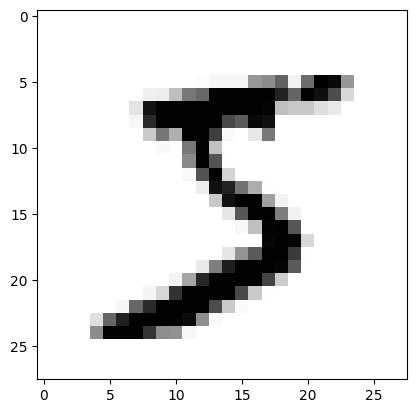

In [8]:
plt.imshow(X_train[0], cmap='Greys')

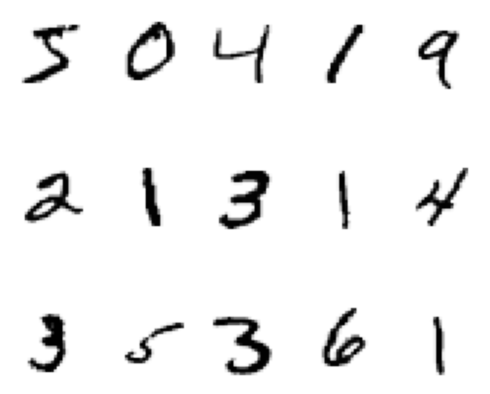

In [9]:
plt.figure(figsize=(5,5))
for k in range(15):
    plt.subplot(3,5,k+1)
    plt.imshow(X_train[k],cmap='Greys')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
X_valid.shape

(10000, 28, 28)

#### Preprocess data
1. normanlize X images to scale 0 to 1
2. one-hot encoding for y

In [11]:
X_train = X_train.reshape(60000,784).astype('float32')
X_valid = X_valid.reshape(10000,784).astype('float32')

In [12]:
X_train /= 255
X_valid /= 255

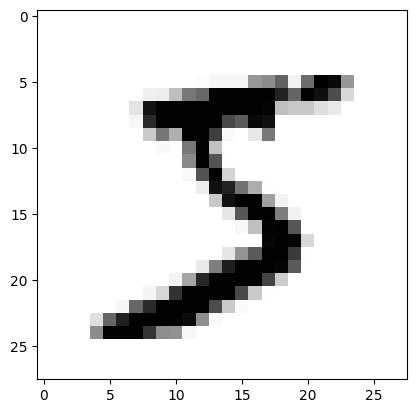

In [13]:
plt.imshow(X_train[0].reshape(28,28),cmap='Greys')

In [14]:
n_classes = 10
y_train = to_categorical(y_train, n_classes)
y_valid = to_categorical(y_valid, n_classes)

In [15]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [16]:
y_train.shape

(60000, 10)

### Design NN Architecture

In [21]:
model =Sequential()

# hidden layer
model.add(Dense(64, activation='relu',input_shape=(784,)))
model.add(BatchNormalization())

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# output layer
model.add(Dense(10, activation='softmax'))

c:\Users\keztan\workspace\.venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,978 (234.29 KB)

 Trainable params: 59,594 (232.79 KB)

 Non-trainable params: 384 (1.50 KB)

#### Compile model

In [23]:
model.compile(loss='categorical_crossentropy', optimizer='nadam', metrics=['accuracy'])

### Train Model

In [24]:
hist = model.fit(X_train,y_train,batch_size=128, epochs=20, verbose=1, validation_data=(X_valid,y_valid))

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7677 - loss: 0.7590 - val_accuracy: 0.9534 - val_loss: 0.1632
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9510 - loss: 0.1644 - val_accuracy: 0.9625 - val_loss: 0.1220
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9650 - loss: 0.1147 - val_accuracy: 0.9664 - val_loss: 0.1056
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9734 - loss: 0.0892 - val_accuracy: 0.9660 - val_loss: 0.1093
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9759 - loss: 0.0780 - val_accuracy: 0.9718 - val_loss: 0.0985
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9794 - loss: 0.0659 - val_accuracy: 0.9699 - val_loss: 0.0988
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9812 - loss: 0.0593 - val_accuracy: 0.9725 - val_loss: 0.0914
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9830 - loss: 0.0534 - val_accuracy: 0.

In [25]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

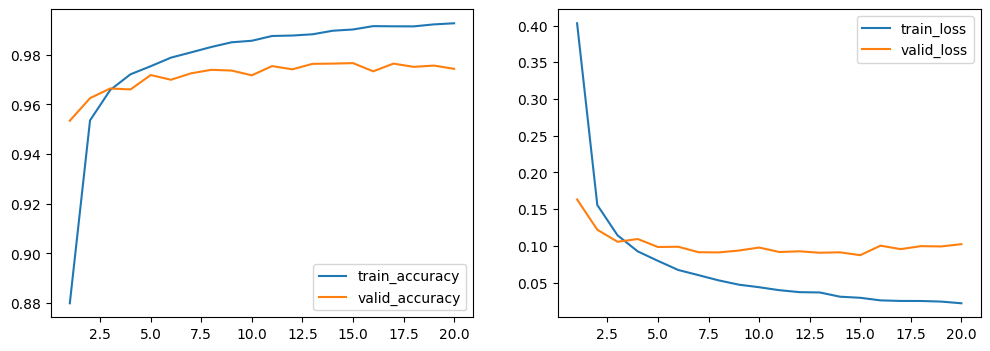

In [26]:
fig, axes = plt.subplots(1,2,figsize=(12,4))

epoches = range(1,21)

axes[0].plot(epoches, hist.history['accuracy'], label = 'train_accuracy')
axes[0].plot(epoches, hist.history['val_accuracy'], label = 'valid_accuracy')
axes[0].axis('tight')
#axes[0].set_ylim([0.8,1])
axes[0].legend()

axes[1].plot(epoches, hist.history['loss'], label = 'train_loss')
axes[1].plot(epoches, hist.history['val_loss'], label = 'valid_loss')
axes[1].axis('tight')
#axes[1].set_ylim([0,0.03])
axes[1].legend()




In [33]:
valid_0= X_valid[0].reshape(1,784)
model.predict(valid_0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


array([[0.00432983, 0.00179577, 0.00345817, 0.00797926, 0.00661158,
        0.00991765, 0.00106704, 0.90128285, 0.00631957, 0.0572383 ]],
      dtype=float32)

In [35]:
model.predict(valid_0).argmax()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


7

In [39]:
X_valid[0].reshape(1,784)

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

### Grid Search Hyperparameters

In [2]:
import keras_tuner as kt

NameError: name 'X_train' is not defined